[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/06_pytorch/20_pytorch_fundamentals.ipynb)

# 📓 Notebook 20 — PyTorch Fundamentals

> **Module:** Deep Learning with PyTorch (Module 6) · **Estimated time:** ~80 minutes · **Difficulty:** Intermediate → Advanced

Everything AI-shaped you have met in this course — the LLMs of Module 8, the transformers behind BERTopic, the DeepTab models of Module 12 — is, underneath, the same thing: a **neural network trained with gradient descent in PyTorch** (or a framework built on it). scikit-learn hands you a finished `.fit()`; **PyTorch hands you the loop *inside* `.fit()`** — and once you can write that loop yourself, no model is a black box anymore.

This is the **first lesson of the PyTorch module**. It builds the four load-bearing ideas in order — **tensors → autograd → `nn.Module` → the training loop** — and then puts them to work on familiar ground: the SaaS churn dataset from NB 17/18, where your first neural network has to earn its keep against a logistic-regression baseline.

> 🧪 **Everything here runs 100% offline — PyTorch is a local library, not a service.** No API key, no network calls: once `torch` is installed, everything trains on your CPU in seconds (the datasets are small on purpose). **Google Colab has PyTorch preinstalled**, so the badge above "just works". Running locally without torch? The setup cell prints the one-line install, and every runtime cell checks `HAS_TORCH` and skips gracefully — the code stays readable either way.

> 🧭 **The mental model for the whole notebook.** *Training is a thermostat loop.* A model makes a guess (**forward**), a loss function measures how wrong it was (**loss**), autograd works out which direction each knob should turn (**backward**), and an optimizer nudges every knob a little (**step**). Repeat a few hundred times and the guesses stop being wrong. Tensors are the material, autograd is the magic, `nn.Module` is the packaging — and the loop is the whole game.

## ✅ Prerequisites

- **NB 8 (NumPy)** — shapes, dtypes, vectorised arithmetic. A tensor *is* a NumPy array with superpowers; every instinct transfers.
- **NB 17–18 (sklearn basics & model evaluation)** — train/test splits, pipelines, ROC-AUC. We reuse the same churn dataset *and* the same honesty rules.
- **NB 19 (feature engineering)** — helpful: hidden layers are feature engineering the model does for itself.
- Comfort with Python classes (NB 6) — `nn.Module` is a class you subclass.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Create and manipulate **`torch.Tensor`s** — shapes, dtypes, NumPy interop, broadcasting — and explain what they add over NumPy arrays (autograd + devices).
2. Use **autograd**: mark a tensor with `requires_grad=True`, call `.backward()`, read `.grad` — and explain why gradients must be **zeroed** between steps.
3. Write **gradient descent by hand** (forward → loss → backward → step) and watch it fit a line, live.
4. Rebuild the same fit idiomatically with **`nn.Module`**, a **loss function** (`nn.MSELoss`, `nn.BCEWithLogitsLoss`) and an **optimizer** (`SGD`, `Adam`) — and map each idiom back to the by-hand version.
5. Explain why hidden layers + **ReLU** let a network learn shapes a straight line can't — *learned* feature engineering.
6. Train an **MLP churn classifier** on the NB 17/18 SaaS dataset, read its **logits → probabilities** correctly, and compare it honestly (ROC-AUC) against a logistic-regression baseline.

## 1. Where scikit-learn stops — and why PyTorch

Module 5 made you dangerous with scikit-learn, and for most **tabular** business problems that is the right tool — we will *prove* that claim, not just state it, in NB 22's bake-off. So why learn PyTorch at all?

| | **scikit-learn** | **PyTorch** |
|---|---|---|
| You write | `model.fit(X, y)` | the loop *inside* `fit` |
| Model space | a fixed menu of estimators | **any** architecture you can express in Python |
| Data it loves | tables | tables, **images, text, audio, sequences, graphs** |
| Pretrained models | few | the entire modern AI ecosystem (HuggingFace, torchvision, …) |
| Gradient engine | hidden | **autograd** — exposed, inspectable, yours |

Four situations where PyTorch earns its keep:

1. **Non-tabular data.** Images, text, audio, sensor sequences — the modalities where deep learning isn't just competitive but *unrivalled*.
2. **Transfer learning.** Start from a model pretrained on millions of examples and adapt it with hundreds of yours (appendix A3 in Module 5 does exactly this).
3. **Custom architectures.** Embeddings for categories (NB 22), two-tower recommenders, anything a fixed estimator menu can't express.
4. **Understanding the AI you already use.** Every LLM call you made in Modules 8–10 ran a stack of PyTorch-style layers. After this module, that sentence means something concrete.

> 🗺️ **Where this module sits.** Module 5's appendix track (A1–A3) is the *condensed reference tour* of PyTorch; this module is the full classroom treatment — slower, exercise-driven, on the course's own data. If you did A1, treat this lesson as consolidation; if not, no matter — it assumes nothing beyond Modules 1–5.

## 2. Setup — smoke test

One import cell for the whole notebook. If `torch` is missing, every runtime cell below checks `HAS_TORCH` and skips gracefully — install it (one line, CPU wheel is fine) to run along.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
    torch.manual_seed(RANDOM_STATE)
    print(f"PyTorch {torch.__version__}  ·  CUDA available: {torch.cuda.is_available()}")
    print("CPU is all this notebook needs — every model here trains in seconds.")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)
    print("Install with:  pip install torch --index-url https://download.pytorch.org/whl/cpu")

/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch 2.12.0  ·  CUDA available: False
CPU is all this notebook needs — every model here trains in seconds.


## 3. Tensors — NumPy arrays with two superpowers

A `torch.Tensor` looks, indexes and broadcasts exactly like the NumPy arrays of NB 8. It adds precisely two things:

1. **Autograd** — a tensor can *remember how it was computed*, so gradients come for free (§4).
2. **Devices** — the same tensor code runs on a CPU today and a GPU tomorrow, unchanged.

Everything else — `.shape`, `.dtype`, slicing, `.mean()`, broadcasting — transfers straight from NumPy. Let's confirm that with data that looks like ours: a small **monthly-recurring-revenue table**, customers × quarters.

In [2]:
if HAS_TORCH:
    # Three ways to make a tensor — exactly parallel to np.zeros / np.random / np.array
    zeros = torch.zeros(2, 3)
    noise = torch.randn(2, 3)                      # standard-normal, like rng.standard_normal
    mrr   = torch.tensor([[420., 435., 455., 470.],   # customer A, Q1..Q4 (EUR)
                          [980., 960., 940., 910.],   # customer B — shrinking!
                          [150., 180., 240., 310.]])  # customer C — growing fast
    print("zeros:", zeros.shape, zeros.dtype)
    print("mrr  :", mrr.shape, "->", mrr.shape[0], "customers ×", mrr.shape[1], "quarters")

    # The NumPy instincts all work:
    print("\nper-customer mean MRR :", mrr.mean(dim=1))     # dim= is NumPy's axis=
    print("per-quarter total MRR :", mrr.sum(dim=0))
    print("Q4 vs Q1 growth       :", (mrr[:, -1] / mrr[:, 0] - 1))

zeros: torch.Size([2, 3]) torch.float32
mrr  : torch.Size([3, 4]) -> 3 customers × 4 quarters

per-customer mean MRR : tensor([445.0000, 947.5000, 220.0000])
per-quarter total MRR : tensor([1550., 1575., 1635., 1690.])
Q4 vs Q1 growth       : tensor([ 0.1190, -0.0714,  1.0667])


In [3]:
if HAS_TORCH:
    # NumPy ↔ torch is a cheap, near-zero-copy round trip — pandas/sklearn stay in the picture
    arr = np.array([[1.0, 2.0], [3.0, 4.0]])
    t   = torch.from_numpy(arr)                     # numpy -> tensor
    back = t.numpy()                                # tensor -> numpy
    print("round trip ok:", np.allclose(arr, back), "| dtype:", t.dtype)

    # Shape gymnastics — the moves you'll use constantly
    x = torch.arange(12.0)                          # 12 values, 1-D
    print("reshape(3,4)  :", x.reshape(3, 4).shape)
    print("unsqueeze(0)  :", x.unsqueeze(0).shape, " <- add a batch axis (1×12)")
    print("view(-1, 6)   :", x.view(-1, 6).shape, "  <- -1 means 'work it out'")

    # Broadcasting, same rules as NB 8: scale each quarter by a seasonal factor
    season = torch.tensor([1.00, 0.95, 1.05, 1.10])          # shape (4,)
    mrr    = torch.tensor([[420., 435., 455., 470.],
                           [980., 960., 940., 910.]])         # shape (2,4)
    print("\nseasonal-adjusted:\n", mrr * season)             # (2,4)*(4,) -> (2,4)

    # ⚠️ One habit to build NOW: models want float32. Doubles (float64) creep in
    # from NumPy — convert deliberately:
    doubles = torch.from_numpy(np.array([1.0, 2.0]))
    print("\nfrom numpy:", doubles.dtype, " -> as model input:", doubles.float().dtype)

round trip ok: True | dtype: torch.float64
reshape(3,4)  : torch.Size([3, 4])
unsqueeze(0)  : torch.Size([1, 12])  <- add a batch axis (1×12)
view(-1, 6)   : torch.Size([2, 6])   <- -1 means 'work it out'

seasonal-adjusted:
 tensor([[ 420.0000,  413.2500,  477.7500,  517.0000],
        [ 980.0000,  912.0000,  986.9999, 1001.0000]])

from numpy: torch.float64  -> as model input: torch.float32


> 💡 **Devices in one paragraph.** Every tensor lives somewhere: `tensor.device` is `cpu` by default, and `tensor.to("cuda")` moves it to a GPU *if you have one*. Nothing in this module needs a GPU — but write `device`-agnostic code from day one (NB 21 §8 gives you the three-line pattern) and your notebook code scales to a GPU box without edits.

---

### ✋ Quick exercise (~2 min) — Tenure, tensor-style

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Five customers have been active for `[3, 14, 27, 41, 58]` **months**. Build a float tensor `months`, convert it to **years** (`/ 12`), then print the mean tenure in years and the tenure of the *longest-standing* customer (`.max()`). One line each — every move is pure NumPy instinct.

In [4]:
# ✍️ Your turn 👇
if HAS_TORCH:
    months = ...      # a float tensor of the five tenures
    years = ...       # months -> years
    # print("mean:", ..., "| max:", ...)
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    months = torch.tensor([3., 14., 27., 41., 58.])
    years = months / 12
    print("mean:", years.mean().item(), "| max:", years.max().item())
```

Broadcasting divides every element by 12, and `.mean()`/`.max()` reduce just like NumPy. `.item()` unwraps a **0-d tensor** into a plain Python float — you'll use it every time you print a loss.
</details>

## 4. Autograd — the machine that turns loss into learning

Here is the first superpower. Mark a tensor with `requires_grad=True`, and PyTorch silently **records every operation** applied to it. Call `.backward()` on the final result, and it replays that recording in reverse — chain rule, automatically — depositing $\partial L / \partial x$ into `x.grad`.

You never write a derivative again. Let's verify it against calculus once, so you trust it forever.

In [5]:
if HAS_TORCH:
    x = torch.tensor(2.0, requires_grad=True)   # "track everything that happens to x"
    y = x**3 + 2*x + 1                           # y = x³ + 2x + 1  (recorded!)
    y.backward()                                 # replay backwards, fill x.grad

    print("y            =", y.item())
    print("autograd dy/dx =", x.grad.item())
    print("calculus 3x²+2 =", 3 * 2.0**2 + 2)    # = 14.0 — they must match

y            = 13.0
autograd dy/dx = 14.0
calculus 3x²+2 = 14.0


Exactly right, and it stays exactly right when "y" is a 175-billion-parameter language model — that is the entire trick of deep learning.

Two rules to tattoo somewhere visible:

- ⚠️ **Gradients accumulate.** `.backward()` *adds into* `.grad`, never overwrites. Between updates you must reset — by hand with `x.grad.zero_()`, or (from §6 on) with `optimizer.zero_grad()`. Forget it and every step secretly contains all previous gradients: training drifts, slowly, maddeningly. It is the #1 PyTorch bug, and it stars in this notebook's 🐞 debug-me.
- ⚠️ **Updates happen outside the recording.** When you nudge a weight, wrap it in `with torch.no_grad():` — the *update* isn't part of the math being differentiated. (Optimizers do this for you; you only see it when stepping by hand, like in the next checkpoint.)

> 🔬 **Want the full anatomy?** Appendix [`A1_pytorch_foundations.ipynb`](../05_machine_learning/A1_pytorch_foundations.ipynb) dissects the computation graph node by node — leaf vs. result tensors, `grad_fn`, and a hand-checked chain rule. Here we take the working picture and move on to what it's *for*.

---

### ✋ Quick exercise (~2 min) — One gradient step, by hand

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A discount knob `d` costs the business `L = (d - 10)²` (the sweet spot is 10%). Starting from `d = 4.0`:

1. compute `L` and call `.backward()`,
2. print the gradient `d.grad`,
3. take **one** gradient-descent step with learning rate `0.25` — inside `torch.no_grad()` — and print the new `d`.

Check your arithmetic: the gradient of $(d-10)^2$ is $2(d-10)$.

In [6]:
# ✍️ Your turn 👇
if HAS_TORCH:
    d = torch.tensor(4.0, requires_grad=True)
    # 1) L = (d - 10)**2 ; L.backward()
    # 2) print d.grad
    # 3) with torch.no_grad(): step d against the gradient (lr=0.25); print new d
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    d = torch.tensor(4.0, requires_grad=True)
    L = (d - 10) ** 2
    L.backward()
    print("gradient:", d.grad.item())        # 2*(4-10) = -12.0
    with torch.no_grad():
        d -= 0.25 * d.grad                    # 4 - 0.25*(-12) = 7.0
    print("new d   :", d.item())              # 7.0 — halfway to the optimum of 10
```

The gradient is **negative** (−12), so "downhill" means *increasing* `d` — the update `d -= lr * grad` moves it from 4 to 7, toward the optimum at 10. That one line **is** `optimizer.step()`; everything after this is packaging.
</details>

## 5. Gradient descent, watched live — fit a line to ad spend

One knob was a warm-up. Now two knobs — a slope `w` and an intercept `b` — fitted to something recognisable: **weekly ad spend vs. sign-ups** for our SaaS company. NB 17 solved this shape of problem with `LinearRegression().fit()`; today *we* are the `.fit()`.

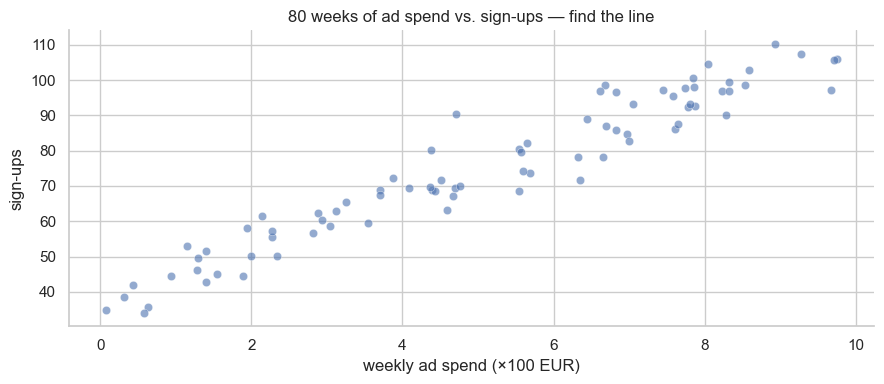

In [7]:
# Synthetic but honest: sign-ups respond to spend at ~+7 sign-ups per extra 100 EUR,
# on a base of ~40, plus noise. (No torch needed to *make* data.)
rng = np.random.default_rng(RANDOM_STATE)
spend_100eur = rng.uniform(0, 10, 80)                          # weekly ad spend, in 100-EUR units
signups = 40 + 7 * spend_100eur + rng.normal(0, 6, 80)          # the "true" process

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(spend_100eur, signups, alpha=0.6, color="#4C72B0", edgecolor="white", lw=0.4)
ax.set(xlabel="weekly ad spend (×100 EUR)", ylabel="sign-ups",
       title="80 weeks of ad spend vs. sign-ups — find the line")
sns.despine(); fig.tight_layout(); plt.show()

In [8]:
if HAS_TORCH:
    X = torch.from_numpy(spend_100eur).float()
    Y = torch.from_numpy(signups).float()

    w = torch.tensor(0.0, requires_grad=True)      # start ignorant: flat line at 0
    b = torch.tensor(0.0, requires_grad=True)
    lr, history = 0.02, []

    for epoch in range(300):
        y_hat = w * X + b                          # 1) FORWARD  — the guess
        loss = ((y_hat - Y) ** 2).mean()           # 2) LOSS     — mean squared error
        loss.backward()                            # 3) BACKWARD — fill w.grad, b.grad
        with torch.no_grad():                      # 4) STEP     — nudge the knobs
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()             # 5) ZERO     — fresh gradients next time
        history.append(loss.item())
        if epoch % 50 == 0 or epoch == 299:
            print(f"epoch {epoch:3d}   loss {loss.item():8.1f}   w={w.item():5.2f}  b={b.item():5.2f}")

    print(f"\nlearned: sign-ups ≈ {w.item():.2f} × spend + {b.item():.2f}   (true: 7 × spend + 40)")

epoch   0   loss   6000.4   w=17.26  b= 2.99
epoch  50   loss    150.2   w=10.84  b=14.82
epoch 100   loss     80.8   w= 9.59  b=22.94
epoch 150   loss     51.8   w= 8.77  b=28.19
epoch 200   loss     39.6   w= 8.25  b=31.59
epoch 250   loss     34.4   w= 7.91  b=33.80
epoch 299   loss     32.3   w= 7.69  b=35.20

learned: sign-ups ≈ 7.69 × spend + 35.20   (true: 7 × spend + 40)


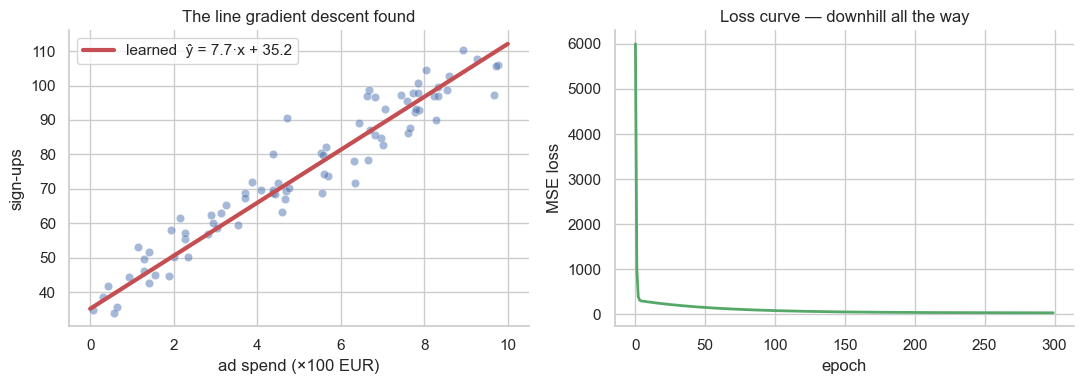

In [9]:
if HAS_TORCH:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(spend_100eur, signups, alpha=0.5, color="#4C72B0", edgecolor="white", lw=0.4)
    gx = np.linspace(0, 10, 50)
    axes[0].plot(gx, w.item() * gx + b.item(), color="#C44E52", lw=3,
                 label=f"learned  ŷ = {w.item():.1f}·x + {b.item():.1f}")
    axes[0].set(xlabel="ad spend (×100 EUR)", ylabel="sign-ups", title="The line gradient descent found")
    axes[0].legend()
    axes[1].plot(history, color="#55A868", lw=2)
    axes[1].set(xlabel="epoch", ylabel="MSE loss", title="Loss curve — downhill all the way")
    sns.despine(); fig.tight_layout(); plt.show()

### The anatomy you just wrote — memorise this shape

```text
for epoch in range(...):
    y_hat = model(X)          # 1. FORWARD   — make a guess
    loss  = loss_fn(y_hat, Y) # 2. LOSS      — how wrong?
    loss.backward()           # 3. BACKWARD  — which way is downhill, per knob?
    optimizer.step()          # 4. STEP      — nudge every knob
    optimizer.zero_grad()     # 5. ZERO      — clean slate for next epoch
```

Five moves. A 2-parameter line and a frontier LLM train with **the same five moves** — only the model in step 1 and the hardware change. Everything else in this module (batching, regularisation, schedules, checkpoints) is refinement *around* this loop, never a replacement for it.

## 6. The same fit, the PyTorch way — `nn.Module`, losses, optimizers

Hand-rolled `w` and `b` don't scale to a thousand weights. PyTorch's idiom bundles them:

| by hand (§5) | idiomatic | what it is |
|---|---|---|
| `w`, `b` tensors | `model = nn.Linear(1, 1)` | a **layer** owning its parameters |
| `((y_hat - Y)**2).mean()` | `loss_fn = nn.MSELoss()` | a ready-made **loss function** |
| `w -= lr * w.grad` (in `no_grad`) | `optimizer.step()` | the update, for **all** parameters at once |
| `w.grad.zero_()` per tensor | `optimizer.zero_grad()` | the reset, for all parameters at once |

`torch.optim.SGD` is literally the §5 update rule; **`Adam`** is the clever default you'll actually use (it adapts a per-parameter learning rate — less lr-fiddling).

In [10]:
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    model = nn.Linear(1, 1)                        # one input feature -> one output
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.02)

    X2 = X.unsqueeze(1)                            # (80,) -> (80,1): layers want (batch, features)
    Y2 = Y.unsqueeze(1)

    for epoch in range(300):
        loss = loss_fn(model(X2), Y2)              # forward + loss in one line
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    w_l, b_l = model.weight.item(), model.bias.item()
    print(f"nn.Linear learned  w={w_l:.2f}  b={b_l:.2f}   (by-hand §5: w={w.item():.2f}  b={b.item():.2f})")
    print("Same math, same answer — now it scales to any number of parameters.")

nn.Linear learned  w=7.68  b=35.25   (by-hand §5: w=7.69  b=35.20)
Same math, same answer — now it scales to any number of parameters.


> 💡 **The `(batch, features)` contract.** Every `nn` layer expects 2-D input: rows = samples, columns = features — exactly a DataFrame's shape. Our 1-D `X` needed `unsqueeze(1)` to become `(80, 1)`. When a PyTorch shape error bites (and it will), check this contract first.

---

### ✋ Quick exercise (~2 min) — Swap in Adam

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Re-run the idiomatic fit with **`torch.optim.Adam`** at `lr=0.5` for only **100 epochs** (a third of SGD's 300). Build a *fresh* `nn.Linear(1, 1)` (so you aren't fine-tuning the already-trained one), reuse `loss_fn`, `X2`, `Y2`, and print the learned `w` and `b`. Does it land near `w≈7, b≈40` in a third of the epochs?

In [11]:
# ✍️ Your turn 👇
if HAS_TORCH:
    torch.manual_seed(0)
    model2 = ...           # fresh nn.Linear(1, 1)
    optimizer2 = ...       # Adam over model2.parameters(), lr=0.5
    # loop 100 epochs: loss -> backward -> step -> zero_grad
    # print model2.weight.item(), model2.bias.item()
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    torch.manual_seed(0)
    model2 = nn.Linear(1, 1)
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.5)
    for epoch in range(100):
        loss = loss_fn(model2(X2), Y2)
        loss.backward()
        optimizer2.step()
        optimizer2.zero_grad()
    print(f"Adam, 100 epochs:  w={model2.weight.item():.2f}  b={model2.bias.item():.2f}")
```

Surprise: it does **not** land there — you should see roughly `w≈10.5, b≈18` (loss ≈118, vs ≈32 after SGD's 300 epochs). Adam sprints early, then its adaptive steps shrink while `b` is still crawling toward its optimum near 38; give it ~500 epochs and it does settle at `w≈7.4, b≈37`. The honest lesson: Adam's per-parameter adaptivity pays off on big, many-parameter, unevenly-scaled problems — on a 2-knob line with one clean feature it has no real edge, and `lr=0.5` was just another hand-picked number. It remains the sensible default for the *networks* in the rest of this module. (And the swap was **one line**; the five-step loop never changed.)
</details>

## 7. From line to network — why hidden layers

Real ad-spend curves aren't straight: doubling the budget doesn't double sign-ups forever — channels **saturate**. A line *cannot* express that, no matter how it's trained. In NB 19 you fixed this kind of mismatch by hand-crafting features (`log(spend)`, `spend²`…). A neural network's pitch is: **stack layers and let the model craft its own features.**

An **MLP** (multi-layer perceptron) is `Linear → ReLU → Linear → ReLU → Linear`. The `ReLU(x) = max(0, x)` between layers is the whole secret: without it, stacked linear layers collapse into one straight line; with it, each hidden unit becomes a *hinge*, and a dozen hinges can bend into almost any curve.

In [12]:
# Saturating data: sign-ups flatten out as spend grows
spend_c = rng.uniform(0, 10, 120)
signups_c = 90 * (1 - np.exp(-0.45 * spend_c)) + rng.normal(0, 4, 120)

if HAS_TORCH:
    Xc = torch.from_numpy(spend_c).float().unsqueeze(1)
    Yc = torch.from_numpy(signups_c).float().unsqueeze(1)

    def fit(model, X, Y, epochs=800, lr=0.01):
        """The five-step loop, boxed up — we'll grow this helper across the module."""
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        for _ in range(epochs):
            loss = nn.MSELoss()(model(X), Y)
            loss.backward(); opt.step(); opt.zero_grad()
        return loss.item()

    torch.manual_seed(RANDOM_STATE)
    line = nn.Linear(1, 1)
    mlp = nn.Sequential(                    # Sequential = "pipe these layers in order"
        nn.Linear(1, 16), nn.ReLU(),
        nn.Linear(16, 16), nn.ReLU(),
        nn.Linear(16, 1),
    )
    print(f"line MSE: {fit(line, Xc, Yc):6.1f}")
    print(f"MLP  MSE: {fit(mlp, Xc, Yc):6.1f}   <- the bend is learnable now")

line MSE:  839.0
MLP  MSE:  130.7   <- the bend is learnable now


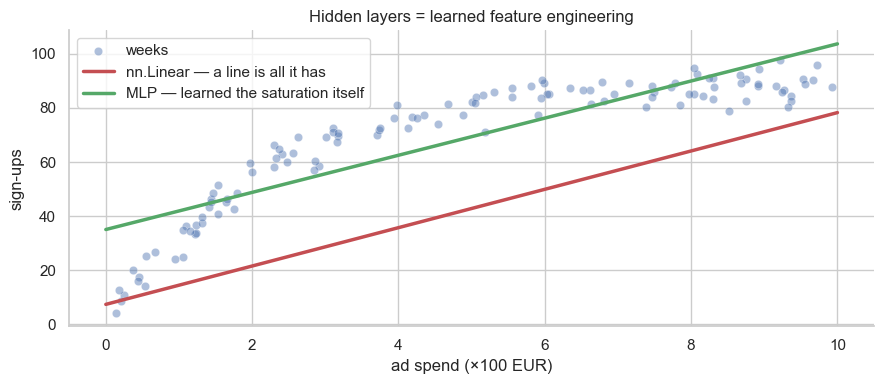

In [13]:
if HAS_TORCH:
    gx = torch.linspace(0, 10, 200).unsqueeze(1)
    with torch.no_grad():                          # inference only — don't record a graph
        line_y, mlp_y = line(gx), mlp(gx)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(spend_c, signups_c, alpha=0.45, color="#4C72B0", edgecolor="white", lw=0.4, label="weeks")
    ax.plot(gx, line_y, color="#C44E52", lw=2.5, label="nn.Linear — a line is all it has")
    ax.plot(gx, mlp_y, color="#55A868", lw=2.5, label="MLP — learned the saturation itself")
    ax.set(xlabel="ad spend (×100 EUR)", ylabel="sign-ups", title="Hidden layers = learned feature engineering")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()

> 🔮 **Predict before you scroll on.** The MLP has `1→16`, `16→16`, `16→1` linear layers. How many learnable parameters is that in total? *(Each `Linear(i, o)` owns `i×o` weights + `o` biases.)* … `(16+16) + (256+16) + (16+1) = 321`. Our line had 2. That 160× jump in capacity is why the next sections obsess over **overfitting** — capacity is a loan, and validation data is how you check you can repay it (NB 21 is entirely about this).

## 8. The real thing — a churn classifier in PyTorch

Time to leave toy curves. We rebuild the **NB 17/18 SaaS churn dataset** — same seed, same 600 customers, same 30% churn rate — and ask the question that module drilled into you: *who is about to leave?* Except this time the model is ours, layer by layer, and it has to beat the classic baseline: `LogisticRegression`.

In [14]:
# Recreate the synthetic churn dataset from NB 17/18 — same seed, same customers
rng = np.random.default_rng(RANDOM_STATE)
n = 600
mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                             size=n, p=[0.15, 0.45, 0.30, 0.10])
last_login_days = rng.integers(0, 90, size=n)

plan_adj = np.array([{"Free": -0.45, "Standard": 0.0, "Premium": 0.15, "Enterprise": 0.35}[p]
                     for p in plan])
happiness = (-0.40*(support_tickets-2.5)/2.0 - 0.80*(last_login_days-45)/30.0
             + 0.35*(np.log1p(mrr_eur)-6.5)/1.5 + 0.30*(months_active-30)/20.0
             + plan_adj + rng.normal(0, 0.30, n))
nps = (40 + 35*happiness + rng.normal(0, 8, n)).clip(-100, 100)
churn_prob = 1/(1+np.exp(-(-1.6 - 2.5*happiness)))
churned = (rng.random(n) < churn_prob).astype(int)

churn_df = pd.DataFrame({"mrr_eur": mrr_eur, "months_active": months_active,
                         "support_tickets": support_tickets, "nps": nps, "plan": plan,
                         "last_login_days": last_login_days, "churned": churned})
print(churn_df.head(3).round(1).to_string())
print(f"\n{n} customers · churn rate {churned.mean():.1%}")

   mrr_eur  months_active  support_tickets   nps     plan  last_login_days  churned
0    823.3             15                1  23.1  Premium               81        1
1    321.2             25                4  39.3  Premium               27        0
2   1124.7              5                3  42.4  Premium               48        1

600 customers · churn rate 30.3%


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot the plan (pandas can do it), split BEFORE scaling — NB 18/19 discipline applies
# to neural nets exactly as it did to sklearn models.
X_df = pd.get_dummies(churn_df.drop(columns=["churned"]), columns=["plan"], dtype=float)
y = churn_df["churned"].values.astype(np.float32)
FEATURES = list(X_df.columns)

X_tr_df, X_te_df, y_tr, y_te = train_test_split(
    X_df, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_tr_df)             # fit on TRAIN ONLY — the golden rule
X_tr = scaler.transform(X_tr_df).astype(np.float32)
X_te = scaler.transform(X_te_df).astype(np.float32)
print(f"train {X_tr.shape} · test {X_te.shape} · {len(FEATURES)} features: {FEATURES}")

train (480, 9) · test (120, 9) · 9 features: ['mrr_eur', 'months_active', 'support_tickets', 'nps', 'last_login_days', 'plan_Enterprise', 'plan_Free', 'plan_Premium', 'plan_Standard']


### Logits, sigmoid, and the loss that reads them

A classifier network ends in `Linear(…, 1)` — one raw, unbounded score per customer, called a **logit**. Push a logit through the **sigmoid** and it becomes a probability: $\sigma(z) = 1/(1+e^{-z})$ maps $-\infty..+\infty$ to $0..1$ (logit 0 ↔ probability 0.5).

The matching loss is **binary cross-entropy**, and PyTorch's `nn.BCEWithLogitsLoss` takes the *logit* directly — it fuses the sigmoid inside for numerical stability. So the pattern is:

- **train** on raw logits with `BCEWithLogitsLoss`,
- **predict** by applying `torch.sigmoid` when you want probabilities.

NB 18's mantra — *the probability, not the label, is the model's real output* — carries over unchanged.

In [16]:
if HAS_TORCH:
    class ChurnMLP(nn.Module):
        """Your first real nn.Module: subclass, define layers in __init__, wire them in forward."""
        def __init__(self, n_features, hidden=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1),
            )
        def forward(self, x):
            return self.net(x).squeeze(1)          # (batch,1) -> (batch,) of logits

    torch.manual_seed(RANDOM_STATE)
    churn_model = ChurnMLP(n_features=X_tr.shape[1])
    n_params = sum(p.numel() for p in churn_model.parameters())
    print(churn_model)
    print(f"\n{n_params:,} learnable parameters")

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

1,409 learnable parameters


In [17]:
if HAS_TORCH:
    Xtr_t, ytr_t = torch.from_numpy(X_tr), torch.from_numpy(y_tr)
    Xte_t, yte_t = torch.from_numpy(X_te), torch.from_numpy(y_te)

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(churn_model.parameters(), lr=1e-3)

    for epoch in range(300):
        churn_model.train()                        # training mode (matters once dropout arrives, NB 21)
        loss = loss_fn(churn_model(Xtr_t), ytr_t)
        loss.backward(); optimizer.step(); optimizer.zero_grad()

        if epoch % 50 == 0 or epoch == 299:
            churn_model.eval()                     # evaluation mode
            with torch.no_grad():
                test_loss = loss_fn(churn_model(Xte_t), yte_t)
            print(f"epoch {epoch:3d}   train loss {loss.item():.3f}   test loss {test_loss.item():.3f}")

epoch   0   train loss 0.645   test loss 0.640
epoch  50   train loss 0.459   test loss 0.442
epoch 100   train loss 0.399   test loss 0.364
epoch 150   train loss 0.384   test loss 0.363
epoch 200   train loss 0.372   test loss 0.364
epoch 250   train loss 0.360   test loss 0.363
epoch 299   train loss 0.345   test loss 0.365


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# The honest scoreboard — same split, same metric, NB 18 rules
baseline = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
base_proba = baseline.predict_proba(X_te)[:, 1]

if HAS_TORCH:
    churn_model.eval()
    with torch.no_grad():
        mlp_proba = torch.sigmoid(churn_model(Xte_t)).numpy()   # logits -> probabilities

    rows = [("LogisticRegression (baseline)", base_proba), ("ChurnMLP (PyTorch)", mlp_proba)]
    print(f"{'model':32}  {'ROC-AUC':>8}  {'acc@0.5':>8}")
    for name, proba in rows:
        print(f"{name:32}  {roc_auc_score(y_te, proba):8.3f}  {accuracy_score(y_te, proba > 0.5):8.3f}")

model                              ROC-AUC   acc@0.5
LogisticRegression (baseline)        0.910     0.842
ChurnMLP (PyTorch)                   0.899     0.817


### Read that scoreboard like a professional

The MLP roughly **matches** logistic regression — it does not crush it. That is the honest, reproducible result on 600 rows of well-behaved tabular data, and it previews this module's closing lesson (NB 22 runs the full bake-off): **on small tabular problems, simple baselines and tree ensembles are brutal competition.** Deep learning's wins come from scale, from non-tabular modalities, from embeddings and transfer learning — not from throwing an MLP at 600 rows and hoping.

So why was this still worth it? Because the *mechanics* you just executed — logits, BCE, train/eval modes, the five-step loop on real features — are **identical** at every scale. You now train neural networks; NB 21 teaches you to train them *well*.

---

### ✋ Quick exercise (~2 min) — Score one new customer

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A new customer signs up: use the ready-made row below (already one-hot in the right column order). Push it through the trained pipeline — `scaler.transform` → float32 tensor → `churn_model` in `eval()` mode under `no_grad()` → `torch.sigmoid` — and print the churn probability. Would you flag them for the retention team?

```python
new_customer = pd.DataFrame([{"mrr_eur": 250.0, "months_active": 4, "support_tickets": 7,
                              "nps": -20.0, "last_login_days": 60, "plan_Enterprise": 0.0,
                              "plan_Free": 1.0, "plan_Premium": 0.0, "plan_Standard": 0.0}])[FEATURES]
```

In [19]:
# ✍️ Your turn 👇
if HAS_TORCH:
    new_customer = pd.DataFrame([{"mrr_eur": 250.0, "months_active": 4, "support_tickets": 7,
                                  "nps": -20.0, "last_login_days": 60, "plan_Enterprise": 0.0,
                                  "plan_Free": 1.0, "plan_Premium": 0.0, "plan_Standard": 0.0}])[FEATURES]
    x_new = ...     # scale, convert to a float32 tensor
    # eval mode + no_grad -> logit -> sigmoid -> print the probability
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    new_customer = pd.DataFrame([{"mrr_eur": 250.0, "months_active": 4, "support_tickets": 7,
                                  "nps": -20.0, "last_login_days": 60, "plan_Enterprise": 0.0,
                                  "plan_Free": 1.0, "plan_Premium": 0.0, "plan_Standard": 0.0}])[FEATURES]
    x_new = torch.from_numpy(scaler.transform(new_customer).astype(np.float32))
    churn_model.eval()
    with torch.no_grad():
        p = torch.sigmoid(churn_model(x_new)).item()
    print(f"churn probability: {p:.1%}  ->  {'🚨 flag for retention' if p > 0.5 else 'looks fine'}")
```

A low-MRR Free-plan customer with 7 tickets, negative NPS and 60 idle days — the model should put this well above 50%. Note the inference liturgy: **same scaler** (fitted on train!), `eval()`, `no_grad()`, then `sigmoid` to turn the logit into a probability.
</details>

## 🧪 Practice exercises

These reuse everything built above (`churn_df`, `scaler`, `Xtr_t`/`ytr_t`, `Xte_t`/`yte_t`, `ChurnMLP`, the trained `churn_model`). Try each before opening the solution.

### Exercise 1 — ⭐ Standardise, tensor-style

Take the numeric columns `["mrr_eur", "nps", "last_login_days"]` from `churn_df` into a float tensor, and standardise each **column** to mean 0 / std 1 using only tensor ops (`.mean(dim=0)`, `.std(dim=0)`, broadcasting). Print the means and stds after, to prove it worked. *(You just reimplemented `StandardScaler`.)*

In [20]:
# Your code here  👇
if HAS_TORCH:
    raw = ...
    standardised = ...
    # print(standardised.mean(dim=0), standardised.std(dim=0))
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    raw = torch.from_numpy(churn_df[["mrr_eur", "nps", "last_login_days"]].to_numpy(np.float32))
    standardised = (raw - raw.mean(dim=0)) / raw.std(dim=0)
    print("means:", standardised.mean(dim=0))    # ≈ 0 (floating-point dust like 1e-8 counts)
    print("stds :", standardised.std(dim=0))     # ≈ 1
```

`raw.mean(dim=0)` has shape `(3,)`; broadcasting stretches it across all 600 rows — one line, no loop. This *is* `StandardScaler.fit_transform`, which is worth seeing once: the sklearn tools you trust are mostly short tensor math with good ergonomics.
</details>

### Exercise 2 — ⭐⭐ Autograd vs. calculus, round 2

Let `f(x) = 5x² − 3x + 2`. At `x = 4.0`, compute the derivative twice: once **by autograd**, once **by hand** (`10x − 3`). Assert they're equal. Then call `.backward()` a *second* time on a fresh `f` computed from the **same** `x` **without** zeroing the gradient first — print `x.grad` and explain the number you see.

In [21]:
# Your code here  👇
if HAS_TORCH:
    x = torch.tensor(4.0, requires_grad=True)
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    x = torch.tensor(4.0, requires_grad=True)
    f = 5 * x**2 - 3 * x + 2
    f.backward()
    hand = 10 * 4.0 - 3                          # = 37.0
    print("autograd:", x.grad.item(), "| by hand:", hand)
    assert x.grad.item() == hand

    f2 = 5 * x**2 - 3 * x + 2                    # fresh forward pass, same x
    f2.backward()                                 # NO zeroing in between...
    print("after 2nd backward:", x.grad.item())  # 74.0 = 37 + 37 — it ACCUMULATED
```

The second backward **adds** another 37 into `.grad` (74 total) instead of replacing it — gradients accumulate by design. In a training loop this silent `+=` is why `optimizer.zero_grad()` exists, and why forgetting it is this notebook's 🐞 bug.
</details>

### Exercise 3 — ⭐⭐ Wider, deeper — or neither?

`ChurnMLP(hidden=32)` was our default. Train two rivals on the same tensors — `hidden=4` (a squeeze) and `hidden=128` (a mansion) — for 300 epochs each (reuse the §8 loop shape; fresh `torch.manual_seed(RANDOM_STATE)` before each). Print test ROC-AUC for all three sizes. Which capacity wins, and by how much? Is the difference big enough to *act* on (NB 18's question)?

In [22]:
# Your code here  👇
if HAS_TORCH:
    def train_size(hidden):
        ...
    # for h in [4, 32, 128]: ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    def train_size(hidden):
        torch.manual_seed(RANDOM_STATE)
        m = ChurnMLP(n_features=X_tr.shape[1], hidden=hidden)
        opt = torch.optim.Adam(m.parameters(), lr=1e-3)
        fn = nn.BCEWithLogitsLoss()
        for _ in range(300):
            loss = fn(m(Xtr_t), ytr_t)
            loss.backward(); opt.step(); opt.zero_grad()
        m.eval()
        with torch.no_grad():
            proba = torch.sigmoid(m(Xte_t)).numpy()
        return roc_auc_score(y_te, proba)

    for h in [4, 32, 128]:
        print(f"hidden={h:<4}  test ROC-AUC {train_size(h):.3f}")
```

`hidden=32` and `hidden=128` land within a whisker of each other (and of logistic regression's 0.910), and even the `hidden=4` squeeze only gives up a couple of hundredths — on 600 rows the signal saturates long before capacity does, and `hidden=128` mostly buys extra overfitting risk, not extra AUC. The professional conclusion: **capacity is not a lever here** (going bigger buys nothing); more informative features or more data would be. NB 21 shows what happens when capacity *does* outrun the data.
</details>

### Exercise 4 — ⭐⭐ Regression rerun — predict NPS

Classification used `BCEWithLogitsLoss`; regression uses `MSELoss` and **no sigmoid**. Predict each customer's `nps` from the *other* numeric features: build `X` from `["mrr_eur", "months_active", "support_tickets", "last_login_days"]` (standardised, train/test split with `random_state=RANDOM_STATE`), train an MLP (`4 → 32 → 32 → 1`) for 400 epochs, and report test **MAE** next to `LinearRegression`'s. *(Everything you need is a copy-paste-and-edit of §8 — that's the point: one loop, any task.)*

In [23]:
# Your code here  👇
if HAS_TORCH:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error

    num = ["mrr_eur", "months_active", "support_tickets", "last_login_days"]
    Xn = churn_df[num].to_numpy(np.float32)
    yn = churn_df["nps"].to_numpy(np.float32)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.2, random_state=RANDOM_STATE)
    sc = StandardScaler().fit(Xn_tr)
    Xt = torch.from_numpy(sc.transform(Xn_tr).astype(np.float32))
    Xv = torch.from_numpy(sc.transform(Xn_te).astype(np.float32))
    yt = torch.from_numpy(yn_tr)

    torch.manual_seed(RANDOM_STATE)
    reg = nn.Sequential(nn.Linear(4, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 1))
    opt = torch.optim.Adam(reg.parameters(), lr=0.01)
    for _ in range(400):
        loss = nn.MSELoss()(reg(Xt).squeeze(1), yt)
        loss.backward(); opt.step(); opt.zero_grad()

    reg.eval()
    with torch.no_grad():
        pred = reg(Xv).squeeze(1).numpy()
    lin = LinearRegression().fit(sc.transform(Xn_tr), yn_tr)
    print(f"MLP MAE   : {mean_absolute_error(yn_te, pred):.1f} NPS points")
    print(f"Linear MAE: {mean_absolute_error(yn_te, lin.predict(sc.transform(Xn_te))):.1f} NPS points")
```

Three edits turned a classifier into a regressor: the loss (`MSELoss`), the head (no sigmoid — raw output *is* the prediction), and the metric (MAE). The five-step loop didn't change at all. Expect the MLP and linear model to land close together — NPS was *built* as a mostly-linear function of these drivers, and the network has to spend data discovering that.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

A colleague's churn training loop is below. It runs without errors, but the loss **lurches** — it falls for a while, then jumps back *up*, and never settles — and they've concluded "the learning rate must be too high". Run it, look at the printed losses, find the **real** bug, and write the fixed loop. *(Hint: §4 tattooed two rules; this violates one of them.)*

In [24]:
# 👇 Buggy on purpose — run it, watch the loss lurch up and down, then write your fix below.
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    buggy = ChurnMLP(n_features=X_tr.shape[1])
    opt = torch.optim.Adam(buggy.parameters(), lr=0.01)
    fn = nn.BCEWithLogitsLoss()

    for epoch in range(120):
        loss = fn(buggy(Xtr_t), ytr_t)
        loss.backward()
        opt.step()
        # (nothing else — what's missing?)
        if epoch % 20 == 0:
            print(f"epoch {epoch:3d}   loss {loss.item():.3f}")
else:
    print("PyTorch not available — skipping.")

epoch   0   loss 0.645
epoch  20   loss 0.640
epoch  40   loss 0.592


epoch  60   loss 0.516
epoch  80   loss 0.653
epoch 100   loss 0.486


<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    fixed = ChurnMLP(n_features=X_tr.shape[1])
    opt = torch.optim.Adam(fixed.parameters(), lr=0.01)
    fn = nn.BCEWithLogitsLoss()
    for epoch in range(120):
        loss = fn(fixed(Xtr_t), ytr_t)
        loss.backward()
        opt.step()
        opt.zero_grad()                      # <- the missing line
        if epoch % 20 == 0:
            print(f"epoch {epoch:3d}   loss {loss.item():.3f}")
```

The bug: **no `opt.zero_grad()`**. Gradients accumulate across epochs, so by epoch 20 each "gradient" is really the *sum of twenty gradients* — a stale, ever-growing direction that has less and less to do with where the loss actually is. (Adam's per-parameter normalisation keeps the steps from exploding outright, which is why you see *lurching* — drops, then jumps back up — rather than a clean blow-up.) The learning rate was innocent. Diagnosis heuristic for your future self: *loss lurching or climbing while the code "looks right" → check zeroing first, lr second.*
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Be the optimizer

Train `ChurnMLP` for 200 epochs **without** `torch.optim`: after each `backward()`, loop over `model.parameters()` inside `torch.no_grad()` and apply `p -= lr * p.grad` yourself, then `p.grad.zero_()`. (Plain SGD, `lr=0.05`.) Confirm the loss actually falls. You will never wonder what `optimizer.step()` does again.

In [25]:
# Your code here  👇
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    manual = ChurnMLP(n_features=X_tr.shape[1])
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    manual = ChurnMLP(n_features=X_tr.shape[1])
    fn, lr = nn.BCEWithLogitsLoss(), 0.05
    for epoch in range(200):
        loss = fn(manual(Xtr_t), ytr_t)
        loss.backward()
        with torch.no_grad():
            for p in manual.parameters():
                p -= lr * p.grad             # optimizer.step(), spelled out
                p.grad.zero_()               # optimizer.zero_grad(), spelled out
        if epoch % 40 == 0:
            print(f"epoch {epoch:3d}   loss {loss.item():.3f}")
```

That inner loop is the entire secret of `torch.optim.SGD`. Fancier optimizers (Adam, momentum) only change the *formula* inside `p -= …` — they keep running statistics per parameter — never the shape of the loop.
</details>

### Stretch exercise B — ⭐⭐⭐ The learning-rate sweep

Learning rate is the single most consequential hyperparameter in deep learning. Train fresh `ChurnMLP`s at `lr ∈ [1e-4, 1e-3, 1e-2, 1e-1, 1.0]` for 150 epochs each, recording the loss history, and plot all five curves on one figure (log-scale y helps). Label the three regimes you see: *crawling*, *healthy*, *unstable*.

In [26]:
# Your code here  👇
if HAS_TORCH:
    histories = {}
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    histories = {}
    for lr in [1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
        torch.manual_seed(RANDOM_STATE)
        m = ChurnMLP(n_features=X_tr.shape[1])
        opt = torch.optim.Adam(m.parameters(), lr=lr)
        fn, hist = nn.BCEWithLogitsLoss(), []
        for _ in range(150):
            loss = fn(m(Xtr_t), ytr_t)
            loss.backward(); opt.step(); opt.zero_grad()
            hist.append(loss.item())
        histories[lr] = hist

    fig, ax = plt.subplots(figsize=(9, 4))
    for lr, hist in histories.items():
        ax.plot(hist, label=f"lr={lr:g}", lw=2)
    ax.set(xlabel="epoch", ylabel="train BCE loss", yscale="log",
           title="One knob, three regimes: crawling · healthy · unstable")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()
```

`1e-4` crawls (still descending at epoch 150), `1e-3`–`1e-2` are the healthy valley, and by `1e-1`–`1.0` the curve goes noisy or climbs — steps so large they leap *across* the valley. Rule of thumb: start at `1e-3` with Adam, sweep in powers of 10, and read the *curve*, not the final number. NB 21 automates this instinct with schedules.
</details>

### Stretch exercise C — ⭐⭐⭐ Three classes, one new loss

Plans, not churn: classify each customer's **plan tier** — collapse to three classes (`Free`=0, `Standard`=1, `Premium`+`Enterprise`=2) — from `["mrr_eur", "months_active", "support_tickets", "nps", "last_login_days"]`. Multiclass changes exactly three things: the head is `Linear(…, 3)` (one logit **per class**), the loss is **`nn.CrossEntropyLoss`** (targets: class indices as a `long` tensor, *not* one-hot), and probabilities come from `torch.softmax(logits, dim=1)`. Train it, print test accuracy, and compare against always guessing the majority class.

In [27]:
# Your code here  👇
if HAS_TORCH:
    tier = churn_df["plan"].map({"Free": 0, "Standard": 1, "Premium": 2, "Enterprise": 2}).values
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    tier = churn_df["plan"].map({"Free": 0, "Standard": 1, "Premium": 2, "Enterprise": 2}).values
    num = ["mrr_eur", "months_active", "support_tickets", "nps", "last_login_days"]
    Xp = churn_df[num].to_numpy(np.float32)
    Xp_tr, Xp_te, t_tr, t_te = train_test_split(Xp, tier, test_size=0.2,
                                                random_state=RANDOM_STATE, stratify=tier)
    sc = StandardScaler().fit(Xp_tr)
    Xt = torch.from_numpy(sc.transform(Xp_tr).astype(np.float32))
    Xv = torch.from_numpy(sc.transform(Xp_te).astype(np.float32))
    tt = torch.from_numpy(t_tr).long()               # CrossEntropyLoss wants class INDICES

    torch.manual_seed(RANDOM_STATE)
    clf3 = nn.Sequential(nn.Linear(5, 32), nn.ReLU(), nn.Linear(32, 3))   # 3 logits
    opt = torch.optim.Adam(clf3.parameters(), lr=0.01)
    for _ in range(300):
        loss = nn.CrossEntropyLoss()(clf3(Xt), tt)
        loss.backward(); opt.step(); opt.zero_grad()

    clf3.eval()
    with torch.no_grad():
        pred = torch.softmax(clf3(Xv), dim=1).argmax(dim=1).numpy()
    majority = np.bincount(t_tr).argmax()
    print(f"MLP accuracy      : {(pred == t_te).mean():.1%}")
    print(f"majority baseline : {(t_te == majority).mean():.1%}")
```

The three-edit pattern again: head width = number of classes, `CrossEntropyLoss` on raw logits with `long` class-index targets, `softmax → argmax` at prediction time. The model beats the majority guess mainly by exploiting `mrr_eur` — plan tiers and revenue are strongly linked by construction. (Predicting a *column of the features* like this is a training exercise, not a business model — in production that would be circular.)
</details>

### Stretch exercise D — ⭐⭐⭐ Logistic regression *is* a one-layer network

Prove the family resemblance: a single `nn.Linear(n_features, 1)` trained with `BCEWithLogitsLoss` **is** logistic regression. Train one on the churn tensors (500 epochs, Adam `lr=0.05`), then compare its test ROC-AUC *and* its learned weights (`model.weight`) against sklearn's `LogisticRegression(C=1e6)` coefficients (near-unregularised, so the two optimise the same objective). How closely do the weight vectors align?

In [28]:
# Your code here  👇
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    torch_logreg = nn.Linear(X_tr.shape[1], 1)
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    torch_logreg = nn.Linear(X_tr.shape[1], 1)
    opt = torch.optim.Adam(torch_logreg.parameters(), lr=0.05)
    fn = nn.BCEWithLogitsLoss()
    for _ in range(500):
        loss = fn(torch_logreg(Xtr_t).squeeze(1), ytr_t)
        loss.backward(); opt.step(); opt.zero_grad()

    torch_logreg.eval()
    with torch.no_grad():
        proba_t = torch.sigmoid(torch_logreg(Xte_t).squeeze(1)).numpy()
    sk = LogisticRegression(C=1e6, max_iter=5000).fit(X_tr, y_tr)

    print(f"torch 1-layer AUC : {roc_auc_score(y_te, proba_t):.3f}")
    print(f"sklearn logreg AUC: {roc_auc_score(y_te, sk.predict_proba(X_te)[:, 1]):.3f}")
    w_t = torch_logreg.weight.detach().numpy().ravel()
    w_s = sk.coef_.ravel()
    cos = w_t @ w_s / (np.linalg.norm(w_t) * np.linalg.norm(w_s))
    print(f"weight-vector cosine similarity: {cos:.3f}")
    print(pd.DataFrame({"feature": FEATURES, "torch_w": w_t.round(2), "sklearn_w": w_s.round(2)}).to_string(index=False))
```

Same objective, two optimizers (Adam vs. LBFGS), nearly identical AUC and a cosine similarity close to 1 — logistic regression really is the one-layer special case. This is the deepest takeaway of the lesson: **classical ML and deep learning are one family**; depth adds learned features on top of the same statistical machine.
</details>

## 🎁 Bonus mini-project — Your own `fit()`

Every experiment above re-typed the same loop. Package it once, properly: write

```python
def fit(model, X, y, *, loss_fn, epochs=300, lr=0.01, X_val=None, y_val=None, verbose=True)
```

that trains any model with Adam and returns a **history dict** `{"train_loss": [...], "val_loss": [...]}` (validation evaluated in `eval()` mode under `no_grad()`, only if provided). Then use it to retrain the churn MLP with the test set as validation, and plot both curves. This function is the seed of NB 21 — where it grows early stopping, checkpointing and schedules — and the great-grandparent of `Trainer` classes in Lightning-style frameworks.

In [29]:
# Your code here  👇
if HAS_TORCH:
    def fit(model, X, y, *, loss_fn, epochs=300, lr=0.01, X_val=None, y_val=None, verbose=True):
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution sketch</b></summary>

```python
if HAS_TORCH:
    def fit(model, X, y, *, loss_fn, epochs=300, lr=0.01, X_val=None, y_val=None, verbose=True):
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        history = {"train_loss": [], "val_loss": []}
        for epoch in range(epochs):
            model.train()
            loss = loss_fn(model(X), y)
            loss.backward(); opt.step(); opt.zero_grad()
            history["train_loss"].append(loss.item())
            if X_val is not None:
                model.eval()
                with torch.no_grad():
                    history["val_loss"].append(loss_fn(model(X_val), y_val).item())
            if verbose and epoch % 50 == 0:
                v = f"   val {history['val_loss'][-1]:.3f}" if X_val is not None else ""
                print(f"epoch {epoch:3d}   train {loss.item():.3f}{v}")
        return history

    torch.manual_seed(RANDOM_STATE)
    m = ChurnMLP(n_features=X_tr.shape[1])
    hist = fit(m, Xtr_t, ytr_t, loss_fn=nn.BCEWithLogitsLoss(),
               X_val=Xte_t, y_val=yte_t, epochs=300)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hist["train_loss"], label="train", lw=2)
    ax.plot(hist["val_loss"], label="validation", lw=2)
    ax.set(xlabel="epoch", ylabel="BCE loss", title="Your fit() — now every experiment is one call")
    ax.legend(); sns.despine(); fig.tight_layout(); plt.show()
```

Notice what the two-curve plot doesn't just whisper but shouts: the train curve keeps falling while the validation curve bottoms out early and then climbs steadily. That gap is **overfitting**, and managing it — dropout, weight decay, early stopping, schedules — is the entire subject of `21_training_neural_networks.ipynb`.
</details>

## 🧠 Key takeaways

- A **tensor** is a NumPy array plus two superpowers: **autograd** (it remembers how it was computed) and **devices** (same code, CPU or GPU). `dim=` is `axis=`; broadcasting is unchanged; models want **float32** and `(batch, features)`.
- **Autograd**: `requires_grad=True` → build the result → `.backward()` → read `.grad`. Gradients **accumulate** — zero them every step, and do weight updates inside `torch.no_grad()`.
- The **five-step training loop** — forward → loss → backward → step → zero — trains everything from a 2-parameter line to an LLM. Memorise the shape.
- **`nn.Module`** packages parameters (`nn.Linear`, `nn.Sequential`, or your own subclass with `forward`); **losses** (`MSELoss`, `BCEWithLogitsLoss`, `CrossEntropyLoss`) pick the task; **optimizers** (`SGD`, and `Adam` as the sane default) own step + zero.
- Hidden layers + **ReLU** = *learned* feature engineering — the network bends where NB 19 had you hand-craft `log`/interaction features.
- Classifiers emit **logits**; train on them with `BCEWithLogitsLoss`, convert with `sigmoid` only when you need probabilities — and keep NB 18's discipline: the probability is the real output, and the baseline must be beaten *honestly*.
- On 600 rows of tabular data the MLP **ties** logistic regression — the sober truth that frames this whole module: deep learning wins on scale, modality and transfer, not by default.

## ✅ Self-assessment

- [ ] Create tensors, reshape them, and reduce along a chosen `dim`
- [ ] Explain the two things a tensor adds over a NumPy array
- [ ] Use `requires_grad` / `.backward()` / `.grad` — and say why `zero_grad` exists
- [ ] Write the five-step training loop from memory
- [ ] Map each by-hand piece (weights, MSE, update, reset) to its `nn` / `optim` idiom
- [ ] Explain what ReLU buys and roughly count an MLP's parameters
- [ ] Choose the right loss for regression, binary and multiclass classification
- [ ] Train a churn MLP and compare it to a sklearn baseline on ROC-AUC

## 🚀 Next step

You can train a neural network. **`21_training_neural_networks.ipynb`** teaches you to train one *well* — mini-batches and `DataLoader`s, the overfitting fight (dropout, weight decay, early stopping), learning-rate schedules, saving/loading, reproducibility, and the four classic bugs, each demonstrated live.